In [ ]:
# AdInsight – Cross Platform Ads Performance Analysis
'''
This project analyzes advertising campaign performance across 
Google Ads, Meta Ads, and TikTok Ads using Python, Pandas, and NumPy.
'''


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("../Dataset/global_ads_performance_dataset.csv")
df.head()

,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38,159,16.74,4803.43,1.80
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60,411,14.99,64126.68,10.41
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35,267,19.07,10489.07,2.06
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20,296,26.47,50505.07,6.45
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77,107,80.97,3369.53,0.39


In [9]:
df.shape

(1800, 14)

In [10]:
df.columns

Index(['date', 'platform', 'campaign_type', 'industry', 'country',
       'impressions', 'clicks', 'CTR', 'CPC', 'ad_spend', 'conversions', 'CPA',
       'revenue', 'ROAS'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1800 non-null   str    
 1   platform       1800 non-null   str    
 2   campaign_type  1800 non-null   str    
 3   industry       1800 non-null   str    
 4   country        1800 non-null   str    
 5   impressions    1800 non-null   int64  
 6   clicks         1800 non-null   int64  
 7   CTR            1800 non-null   float64
 8   CPC            1800 non-null   float64
 9   ad_spend       1800 non-null   float64
 10  conversions    1800 non-null   int64  
 11  CPA            1800 non-null   float64
 12  revenue        1800 non-null   float64
 13  ROAS           1800 non-null   float64
dtypes: float64(6), int64(3), str(5)
memory usage: 197.0 KB


In [12]:
df.isnull().sum()

date             0
platform         0
campaign_type    0
industry         0
country          0
impressions      0
clicks           0
CTR              0
CPC              0
ad_spend         0
conversions      0
CPA              0
revenue          0
ROAS             0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [18]:
total_spend = df.ad_spend.sum()
print(f"Total Ad Spend ${total_spend:,.2f}")

Total Ad Spend $11,108,749.09


In [25]:
total_clicks = df.clicks.sum()
print(f"Total Clicks: {total_clicks:,.2f}")

Total Clicks: 7,132,816.00


In [23]:
total_conversions = df.conversions.sum()
print(f"Total Conversions: {total_conversions:,.2f}")

Total Conversions: 326,812.00


In [28]:
conversion_rate = total_conversions / total_clicks
print(f"Conversion Rate: {conversion_rate:.2%}")

Conversion Rate: 4.58%


In [ ]:
#platform performance analysis
platform_performance = df.groupby("platform")[["ad_spend","clicks", "conversions", "revenue"]].sum()
print(platform_performance)

              ad_spend   clicks  conversions      revenue
platform                                                 
Google Ads  6349268.91  2936149       131098  22033744.95
Meta Ads    2106061.67  1596736        73262  11926045.79
TikTok Ads  2653418.51  2599931       122452  20223540.07


In [30]:
platform_performance["converstion_rate"] = (
    platform_performance["conversions"] / platform_performance["clicks"]
)
platform_performance

,ad_spend,clicks,conversions,revenue,converstion_rate
platform,,,,,
Google Ads,6349268.91,2936149,131098,22033744.95,0.044650
Meta Ads,2106061.67,1596736,73262,11926045.79,0.045882
TikTok Ads,2653418.51,2599931,122452,20223540.07,0.047098


In [32]:
platform_performance["cost_per_conversion"] = platform_performance["ad_spend"] / platform_performance["conversions"]
platform_performance

,ad_spend,clicks,conversions,revenue,converstion_rate,cost_per_conversion
platform,,,,,,
Google Ads,6349268.91,2936149,131098,22033744.95,0.044650,48.431470
Meta Ads,2106061.67,1596736,73262,11926045.79,0.045882,28.746986
TikTok Ads,2653418.51,2599931,122452,20223540.07,0.047098,21.669050


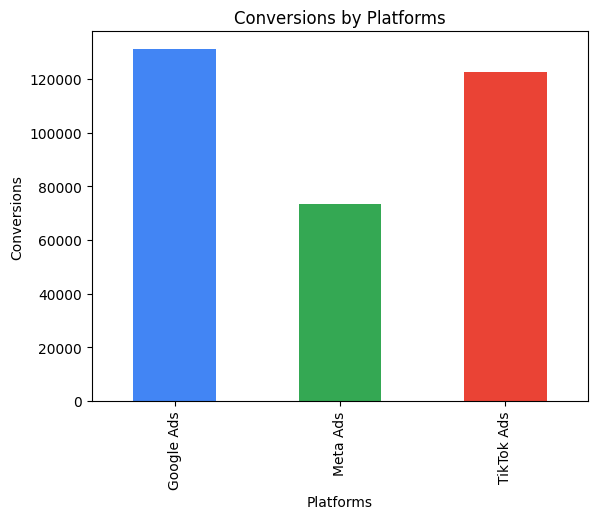

In [37]:
platform_performance["conversions"].plot(kind="bar", color=["#4285F4","#34A853","#EA4335"])
plt.title("Conversions by Platforms")
plt.ylabel("Conversions")
plt.xlabel("Platforms")
plt.show()

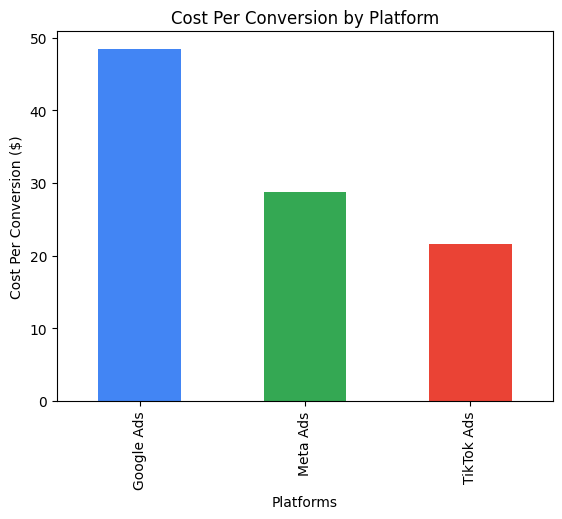

In [38]:
platform_performance["cost_per_conversion"].plot(kind="bar", color = ["#4285F4","#34A853","#EA4335"])
plt.title("Cost Per Conversion by Platform")
plt.ylabel("Cost Per Conversion ($)")
plt.xlabel("Platforms")
plt.show()

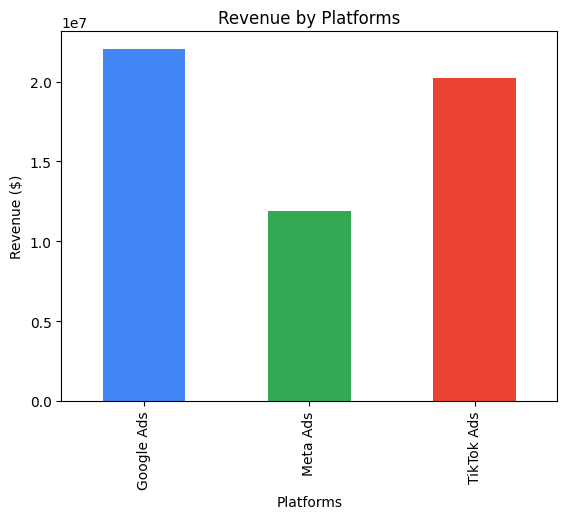

In [39]:
platform_performance["revenue"].plot(kind="bar", color =["#4285F4","#34A853", "#EA4335"])
plt.title("Revenue by Platforms")
plt.ylabel("Revenue ($)")
plt.xlabel("Platforms")
plt.show()


In [40]:
platform_performance["ROAS"] = platform_performance["revenue"] / platform_performance["ad_spend"]
platform_performance

,ad_spend,clicks,conversions,revenue,converstion_rate,cost_per_conversion,ROAS
platform,,,,,,,
Google Ads,6349268.91,2936149,131098,22033744.95,0.044650,48.431470,3.470281
Meta Ads,2106061.67,1596736,73262,11926045.79,0.045882,28.746986,5.662724
TikTok Ads,2653418.51,2599931,122452,20223540.07,0.047098,21.669050,7.621693


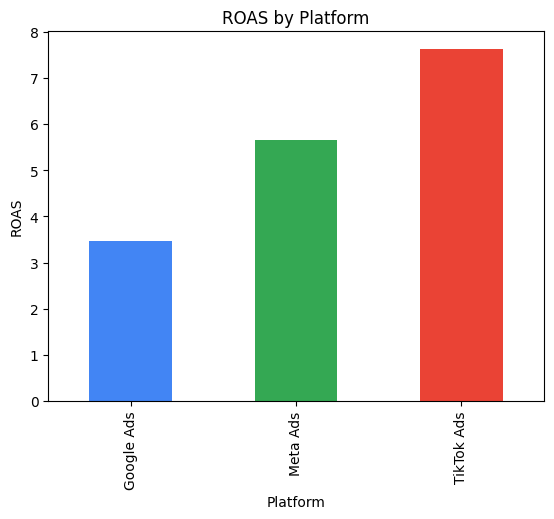

In [42]:
platform_performance["ROAS"].plot(kind="bar" ,color = ["#4285F4","#34A853","#EA4335"])
plt.title("ROAS by Platform")
plt.ylabel("ROAS")
plt.xlabel("Platform")
plt.show()

In [44]:
#industry performance analysis
industry_performance = df.groupby("industry")[["ad_spend", "clicks", "conversions", "revenue"]].sum()
industry_performance

,ad_spend,clicks,conversions,revenue
industry,,,,
E-commerce,1923987.08,1280139,57486,9637279.69
EdTech,2296978.52,1502152,67257,11549934.43
Fintech,2271537.73,1412347,65121,10173311.23
Healthcare,2258683.92,1387123,65687,10930814.04
SaaS,2357561.84,1551055,71261,11891991.42


In [45]:
industry_performance["conversion_rate"] = industry_performance["conversions"] / industry_performance["clicks"]
industry_performance

,ad_spend,clicks,conversions,revenue,conversion_rate
industry,,,,,
E-commerce,1923987.08,1280139,57486,9637279.69,0.044906
EdTech,2296978.52,1502152,67257,11549934.43,0.044774
Fintech,2271537.73,1412347,65121,10173311.23,0.046108
Healthcare,2258683.92,1387123,65687,10930814.04,0.047355
SaaS,2357561.84,1551055,71261,11891991.42,0.045944


In [ ]:
#Healthcare campaigns convert the best.

In [46]:
industry_performance["ROAS"] = industry_performance["revenue"] / industry_performance["ad_spend"]
industry_performance

,ad_spend,clicks,conversions,revenue,conversion_rate,ROAS
industry,,,,,,
E-commerce,1923987.08,1280139,57486,9637279.69,0.044906,5.009015
EdTech,2296978.52,1502152,67257,11549934.43,0.044774,5.028316
Fintech,2271537.73,1412347,65121,10173311.23,0.046108,4.478601
Healthcare,2258683.92,1387123,65687,10930814.04,0.047355,4.839462
SaaS,2357561.84,1551055,71261,11891991.42,0.045944,5.044191


In [ ]:
#$1 spent on SaaS ads generates ≈ $5.04 revenue.

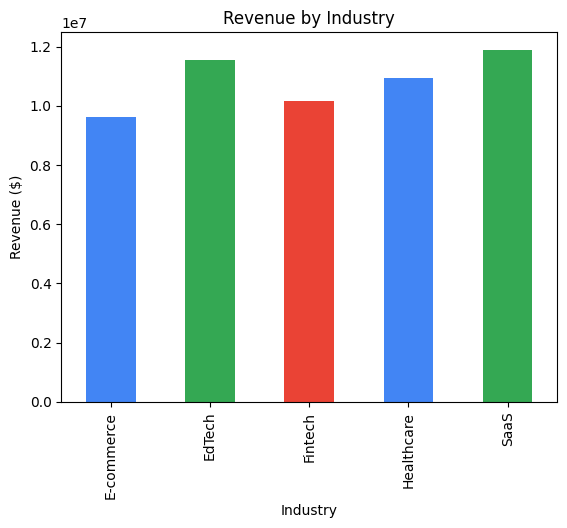

In [47]:
industry_performance["revenue"].plot(kind="bar", color=["#4285F4","#34A853","#EA4335"])
plt.title("Revenue by Industry")
plt.ylabel("Revenue ($)")
plt.xlabel("Industry")
plt.show()

In [ ]:
#highest revenue SaaS = $11.89M
'''Industry Performance Insights

Healthcare campaigns show the highest conversion rate (4.73%), 
indicating that users interacting with healthcare advertisements 
are more likely to complete the desired action.

SaaS campaigns generate the highest revenue ($11.89M) and the 
highest ROAS (5.04), meaning SaaS advertising produces the 
strongest financial returns.
'''

In [ ]:
df.campaign_type.unique()

<StringArray>
['Search', 'Video', 'Shopping', 'Display']
Length: 4, dtype: str

In [49]:
df.campaign_type.value_counts()

campaign_type
Search      477
Video       456
Shopping    447
Display     420
Name: count, dtype: int64

In [50]:
campaign_performance = df.groupby("campaign_type")[["ad_spend","clicks", "conversions", "revenue",]].sum()
campaign_performance

,ad_spend,clicks,conversions,revenue
campaign_type,,,,
Display,2644735.12,1638396,76869,12798903.17
Search,2868006.85,1898227,90641,15218470.85
Shopping,2799548.64,1785310,80074,12824695.60
Video,2796458.48,1810883,79228,13341261.19


In [51]:
campaign_performance["conversion_rate"] = campaign_performance["conversions"] / campaign_performance["clicks"]
campaign_performance

,ad_spend,clicks,conversions,revenue,conversion_rate
campaign_type,,,,,
Display,2644735.12,1638396,76869,12798903.17,0.046917
Search,2868006.85,1898227,90641,15218470.85,0.047750
Shopping,2799548.64,1785310,80074,12824695.60,0.044852
Video,2796458.48,1810883,79228,13341261.19,0.043751


In [ ]:
#Search has High Conversion Rate

In [52]:
campaign_performance["ROAS"] = campaign_performance["revenue"] / campaign_performance["ad_spend"]
campaign_performance

,ad_spend,clicks,conversions,revenue,conversion_rate,ROAS
campaign_type,,,,,,
Display,2644735.12,1638396,76869,12798903.17,0.046917,4.839389
Search,2868006.85,1898227,90641,15218470.85,0.047750,5.306288
Shopping,2799548.64,1785310,80074,12824695.60,0.044852,4.580987
Video,2796458.48,1810883,79228,13341261.19,0.043751,4.770770


In [ ]:
#Serach has High ROAS

Text(0.5, 0, 'Campaign Type')

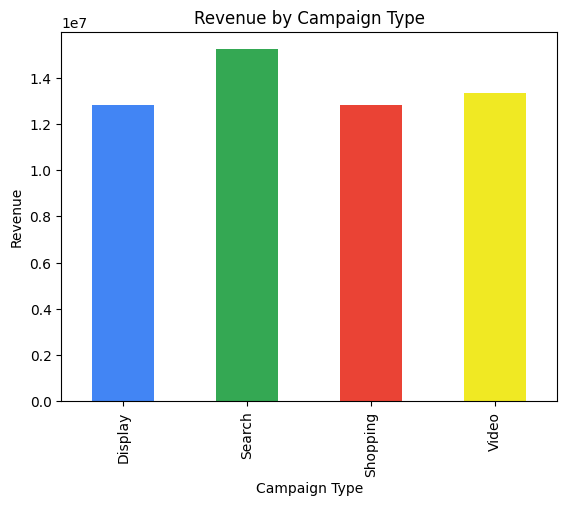

In [53]:
campaign_performance["revenue"].plot(kind="bar", color= ["#4285F4","#34A853","#EA4335", "#F0E923"])
plt.title("Revenue by Campaign Type")
plt.ylabel("Revenue")
plt.xlabel("Campaign Type")


In [ ]:
#Search has High Revenue
#Video and Shopping campaigns show slightly lower efficiency

In [54]:
df.country.unique()

<StringArray>
['UAE', 'UK', 'USA', 'Germany', 'Canada', 'India', 'Australia']
Length: 7, dtype: str

In [56]:
country_performance = df.groupby("country")[["ad_spend","clicks", "conversions", "revenue"]].sum()
country_performance

,ad_spend,clicks,conversions,revenue
country,,,,
Australia,1586264.94,960925,45869,7921847.84
Canada,1643262.54,1034804,46243,7867323.12
Germany,1551062.17,994571,44768,7694838.61
India,1438741.76,1015783,46767,7909606.26
UAE,1614677.33,1056222,48345,7939594.41
UK,1547153.48,1006651,46842,7659544.29
USA,1727586.87,1063860,47978,7190576.28


In [58]:
country_performance["conversion_rate"] = (
    country_performance["conversions"] /
    country_performance["clicks"]
)
country_performance

,ad_spend,clicks,conversions,revenue,conversion_rate
country,,,,,
Australia,1586264.94,960925,45869,7921847.84,0.047734
Canada,1643262.54,1034804,46243,7867323.12,0.044688
Germany,1551062.17,994571,44768,7694838.61,0.045012
India,1438741.76,1015783,46767,7909606.26,0.046040
UAE,1614677.33,1056222,48345,7939594.41,0.045772
UK,1547153.48,1006651,46842,7659544.29,0.046533
USA,1727586.87,1063860,47978,7190576.28,0.045098


In [59]:
country_performance["ROAS"] = (
    country_performance["revenue"] /
    country_performance["ad_spend"]
)
country_performance

,ad_spend,clicks,conversions,revenue,conversion_rate,ROAS
country,,,,,,
Australia,1586264.94,960925,45869,7921847.84,0.047734,4.994026
Canada,1643262.54,1034804,46243,7867323.12,0.044688,4.787624
Germany,1551062.17,994571,44768,7694838.61,0.045012,4.961012
India,1438741.76,1015783,46767,7909606.26,0.046040,5.497586
UAE,1614677.33,1056222,48345,7939594.41,0.045772,4.917140
UK,1547153.48,1006651,46842,7659544.29,0.046533,4.950733
USA,1727586.87,1063860,47978,7190576.28,0.045098,4.162208


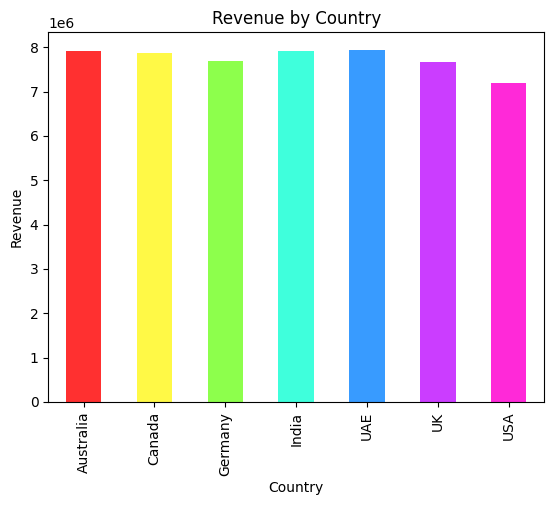

In [60]:
country_performance["revenue"].plot(kind="bar", color = ["#FF3030","#FFF946", "#8DFF4C", "#3FFFDC", "#389BFF", "#CB3DFF", "#FF29D8"])

plt.title("Revenue by Country")
plt.ylabel("Revenue")
plt.xlabel("Country")

plt.show()

In [ ]:
'''
Country Performance Insights

India demonstrates the highest ROAS (5.49), indicating that advertising
spend in India generates the strongest financial return.

Australia shows the highest conversion rate (4.77%), suggesting that
users in this region are most responsive to advertising campaigns.

The United States shows the lowest ROAS (4.16), indicating relatively
lower profitability compared to other markets in this dataset.
'''

In [61]:
platform_industry = df.groupby(
    ["platform", "industry"]
)[["ad_spend","revenue","conversions"]].sum()

platform_industry

ad_spend     revenue  conversions
platform   industry                                       
Google Ads E-commerce  1086590.00  4021404.29        23154
           EdTech      1280698.01  4581077.00        26554
           Fintech     1362038.01  5033529.91        30350
           Healthcare  1292613.31  4033233.63        24529
           SaaS        1327329.58  4364500.12        26511
Meta Ads   E-commerce   409120.81  2034150.28        13704
           EdTech       441250.76  2745051.10        15513
           Fintech      427253.02  2063789.93        13938
           Healthcare   445677.15  2901099.26        17003
           SaaS         382759.93  2181955.22        13104
TikTok Ads E-commerce   428276.27  3581725.12        20628
           EdTech       575029.75  4223806.33        25190
           Fintech      482246.70  3075991.39        20833
           Healthcare   520393.46  3996481.15        24155
           SaaS         647472.33  5345536.08        31646

In [62]:
platform_industry["ROAS"] = (
    platform_industry["revenue"] /
    platform_industry["ad_spend"]
)

platform_industry

ad_spend     revenue  conversions      ROAS
platform   industry                                                 
Google Ads E-commerce  1086590.00  4021404.29        23154  3.700940
           EdTech      1280698.01  4581077.00        26554  3.577016
           Fintech     1362038.01  5033529.91        30350  3.695587
           Healthcare  1292613.31  4033233.63        24529  3.120217
           SaaS        1327329.58  4364500.12        26511  3.288181
Meta Ads   E-commerce   409120.81  2034150.28        13704  4.972004
           EdTech       441250.76  2745051.10        15513  6.221068
           Fintech      427253.02  2063789.93        13938  4.830369
           Healthcare   445677.15  2901099.26        17003  6.509419
           SaaS         382759.93  2181955.22        13104  5.700584
TikTok Ads E-commerce   428276.27  3581725.12        20628  8.363118
           EdTech       575029.75  4223806.33        25190  7.345370
           Fintech      482246.70  3075991.39        20833  6.378460
           Healthcare   520393.46  3996481.15        24155  7.679730
           SaaS         647472.33  5345536.08        31646  8.256007

In [63]:
pivot_table = platform_industry["ROAS"].unstack()

pivot_table

industry,E-commerce,EdTech,Fintech,Healthcare,SaaS
platform,,,,,
Google Ads,3.700940,3.577016,3.695587,3.120217,3.288181
Meta Ads,4.972004,6.221068,4.830369,6.509419,5.700584
TikTok Ads,8.363118,7.345370,6.378460,7.679730,8.256007


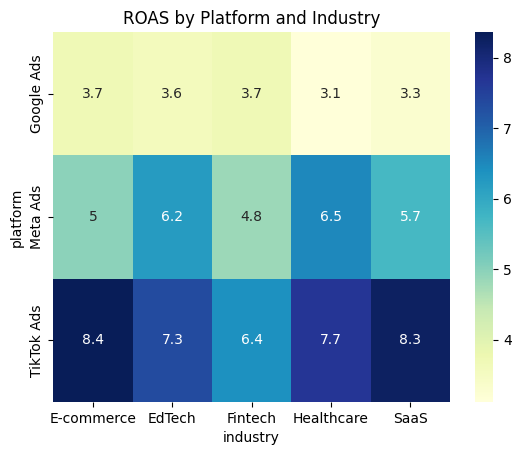

In [64]:
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu")

plt.title("ROAS by Platform and Industry")

plt.show()

In [66]:
platform_performance.reset_index().to_json(
    "platform.json",
    orient="records"
)

In [67]:
industry_performance.reset_index().to_json(
    "industry.json",
    orient="records"
)


In [68]:
campaign_performance.reset_index().to_json(
    "campaign.json",
    orient="records"
)

In [69]:
country_performance.reset_index().to_json(
    "country.json",
    orient="records"
)

In [71]:
pivot_table.reset_index().to_json(
    "platform_industry.json",
    orient="records"
)


In [74]:
platform_industry = df.groupby(["platform","industry"])[["ad_spend","revenue"]].sum().reset_index()

platform_industry["ROAS"] = platform_industry["revenue"] / platform_industry["ad_spend"]

platform_industry.to_json("platform_industry.json", orient="records", indent=2)